# 🛳️ **Diabetes Prediction — CatBoost**
Projeto de classificação supervisionada para detecção de risco de diabetes utilizando o algoritmo CatBoost, com foco no tratamento nativo de categorias, robustez estatística e otimização de performance via Random Search e calibração de threshold.

**Destaques**
* **Pipeline de Dados:** Integração com o preprocessador `v3a`, otimizando a engenharia de atributos para modelos baseados em gradiente.
* **Comparativo de Tuning:** Avaliação entre o modelo Baseline e o Modelo 2 (Exploratório/Random Search).
* **Rigor Estatístico:** Uso de `StratifiedKFold`, ROC-AUC e Teste-T pareado para validar a relevância das melhorias.
* **Decisão Baseada em Threshold:** Busca automática do limiar de probabilidade ideal para maximizar a acurácia de teste.
* **Análise de Importância:** Mapeamento detalhado das variáveis que mais impactam o risco contínuo e a probabilidade global.


## 1.Bibliotecas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from pathlib import Path
import time

from scipy.stats import ttest_rel

# sklearn
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             average_precision_score,roc_curve)

from sklearn.base import BaseEstimator, TransformerMixin, clone

# Importações locais
from setup_notebook import setup_path
setup_path()
from src.model_utils import *
from src.preprocess_utils_diab3a import * #(NOVO atualizações)
from src.plot_metrica_class import *

print("\n#Processo iniciado em:", time.strftime("%H:%M:%S"))
start_inicial = time.time()


#Processo iniciado em: 16:33:29


## 2. Dataload & Preprocessamento com joblib


In [2]:
BASE = Path.cwd().parent   
# =====================================================
# ⚙️ 0. carregamento dos preprocessador 
# =====================================================
PP3a = joblib.load(BASE/'src'/'preprocess_diabetes_v3a.joblib')['preprocessador']

# # =====================================================
# # 📁 1. Leitura dos dados & Separação das bases
# # =====================================================

DATA_DIR = BASE / "data" / "raw"
X_train = pd.read_csv(DATA_DIR / "X_train_raw.csv").sample(49000,random_state=42).reset_index(drop=True)
X_val  = pd.read_csv(DATA_DIR / "X_test_raw.csv").sample(21000,random_state=42)
y_train = pd.read_csv(DATA_DIR / "y_train_raw.csv").sample(49000,random_state=42).values.ravel()
y_val  = pd.read_csv(DATA_DIR / "y_test_raw.csv").sample(21000,random_state=42)
mtd_scoring='roc_auc'

# # # =====================================================
# # #  🤖 3.Definição dos Modelos
# # # =====================================================
DATA_MODELS= BASE /"models" 
pipe_CBT0 = joblib.load(DATA_MODELS / 'modelo_CBT_final_base.roc_auc_v3a.joblib')
pipe_CBT1 = joblib.load(DATA_MODELS / 'modelo_CBT_final_randsearch.roc_auc_v3a.joblib')
print("\n#Processo iniciado em:", time.strftime("%H:%M:%S"))


#Processo iniciado em: 16:33:30


## 3. Modelos
### 3.1 Baseline

In [3]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R0=evaluate_model(pipe_CBT0 ,X_train,y_train,X_val,y_val,modelname='Baseline')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R0['y_pred'][0]))
cm=confusion_matrix(y_val, R0['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 16:33:30

                         📍 RESULTADOS BASELINE                        
📊 CROSS-VALIDATION
   Média roc_auc:                0.7094 ± 0.0031

✅ TEST SET
   Padrão (0.5):                  0.6755
   Otimizado:                     0.6717 (threshold = 0.520)
   ROC-AUC:                       0.7092
   Avg precision:                 0.7993
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.60      0.40      0.48      7861
         1.0       0.70      0.84      0.76     13139

    accuracy                           0.68     21000
   macro avg       0.65      0.62      0.62     21000
weighted avg       0.66      0.68      0.66     21000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         3125        4736       
Real 1         2079        11060      
────────────────────────────────────────────────────────

### 3.2 Modelo 1

In [4]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R1=evaluate_model(pipe_CBT1,X_train,y_train,X_val,y_val,modelname='CBT 1')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R1['y_pred'][0]))
cm=confusion_matrix(y_val, R1['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 16:35:34

                          📍 RESULTADOS CBT 1                          
📊 CROSS-VALIDATION
   Média roc_auc:                0.7058 ± 0.0018

✅ TEST SET
   Padrão (0.5):                  0.6721
   Otimizado:                     0.6711 (threshold = 0.520)
   ROC-AUC:                       0.7094
   Avg precision:                 0.7990
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.59      0.40      0.48      7861
         1.0       0.70      0.84      0.76     13139

    accuracy                           0.67     21000
   macro avg       0.65      0.62      0.62     21000
weighted avg       0.66      0.67      0.65     21000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         3115        4746       
Real 1         2139        11000      
────────────────────────────────────────────────────────

## 4 Relatorio de Classificação

In [5]:
# =====================================================
# A. Avaliação comparativa dos modelos RF (Baseline)
# =====================================================
# Nesta etapa é realizada uma análise comparativa completa entre os
# modelos testados. O objetivo é avaliar
# desempenho, estabilidade e diferença estatística entre os modelos.
# Calcula os scores de validação cruzada para cada modelo(roc-auc)

# -----------------------------------------------------
# A.1 Validação cruzada ROC-AUC & acuraccy
# -----------------------------------------------------

s0_auc = R0['cv_scores'][0]
s1_auc = R1['cv_scores'][0]

cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


print(f"Iniciando Cross-Validation Accuracy ...")
start_m = time.time()
s0_acc = cross_val_score(pipe_CBT0, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ Baseline - ⏱️ {time.time() - start_m:5.2f}s")
start_m = time.time()
s1_acc = cross_val_score(pipe_CBT1, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 1 - ⏱️ {time.time() - start_m:5.2f}s")


# -----------------------------------------------------
# A.2 Probabilidades no conjunto de teste
# -----------------------------------------------------
y_prob0 = R0['y_probs'][0]
y_prob1 = R1['y_probs'][0]

# -----------------------------------------------------
# A.4 Estrutura dos dados para relatorio
# -----------------------------------------------------
models_list = [
    ('Modelo 0  (base)' , pipe_CBT0, s0_auc, s0_acc, y_prob0,R0['best_t'][0]),
    ('Modelo 1  (base)' , pipe_CBT0, s0_auc, s0_acc, y_prob0, R0['best_t'][0]),
    ('Modelo 2  (exp) ', pipe_CBT1, s1_auc, s1_acc, y_prob1   ,R1['best_t'][0]),
]
# -----------------------------------------------------
# A.5 Geração do relatório estatístico
# -----------------------------------------------------

print(f" Construindo relatorio ...")
df_results,W = gerar_relatorio_estatistico2(models_list,X_train, y_train,X_val, y_val)

Iniciando Cross-Validation Accuracy ...
    ✅ Baseline - ⏱️ 123.74s
    ✅ modelo 1 - ⏱️ 126.12s
 Construindo relatorio ...
                      RELATÓRIO DE DESEMPENHO E ESTABILIDADE ESTATÍSTICA                       
          Modelo  CV ROC Mean  CV ROC Std  CV ACC Mean  CV ACC Std  Test ROC-AUC  Test ACC (0.5)  Best Thresh  Test ACC (Opt)
Modelo 0  (base)       0.7094      0.0031       0.6738      0.0027        0.7092          0.6755         0.52          0.6717
Modelo 1  (base)       0.7094      0.0031       0.6738      0.0027        0.7092          0.6755         0.52          0.6717
Modelo 2  (exp)        0.7058      0.0018       0.6718      0.0017        0.7094          0.6721         0.52          0.6711

                     ANÁLISE DE SIGNIFICÂNCIA ESTATÍSTICA (T-TEST PAREADO)                     
Modelo 1  (base) vs Modelo 2  (exp) : p-value = 0.0769 | Diferença Significativa? NÃO

                             CONCLUSÃO TÉCNICA AUTOMÁTICA ROC_AUC                            

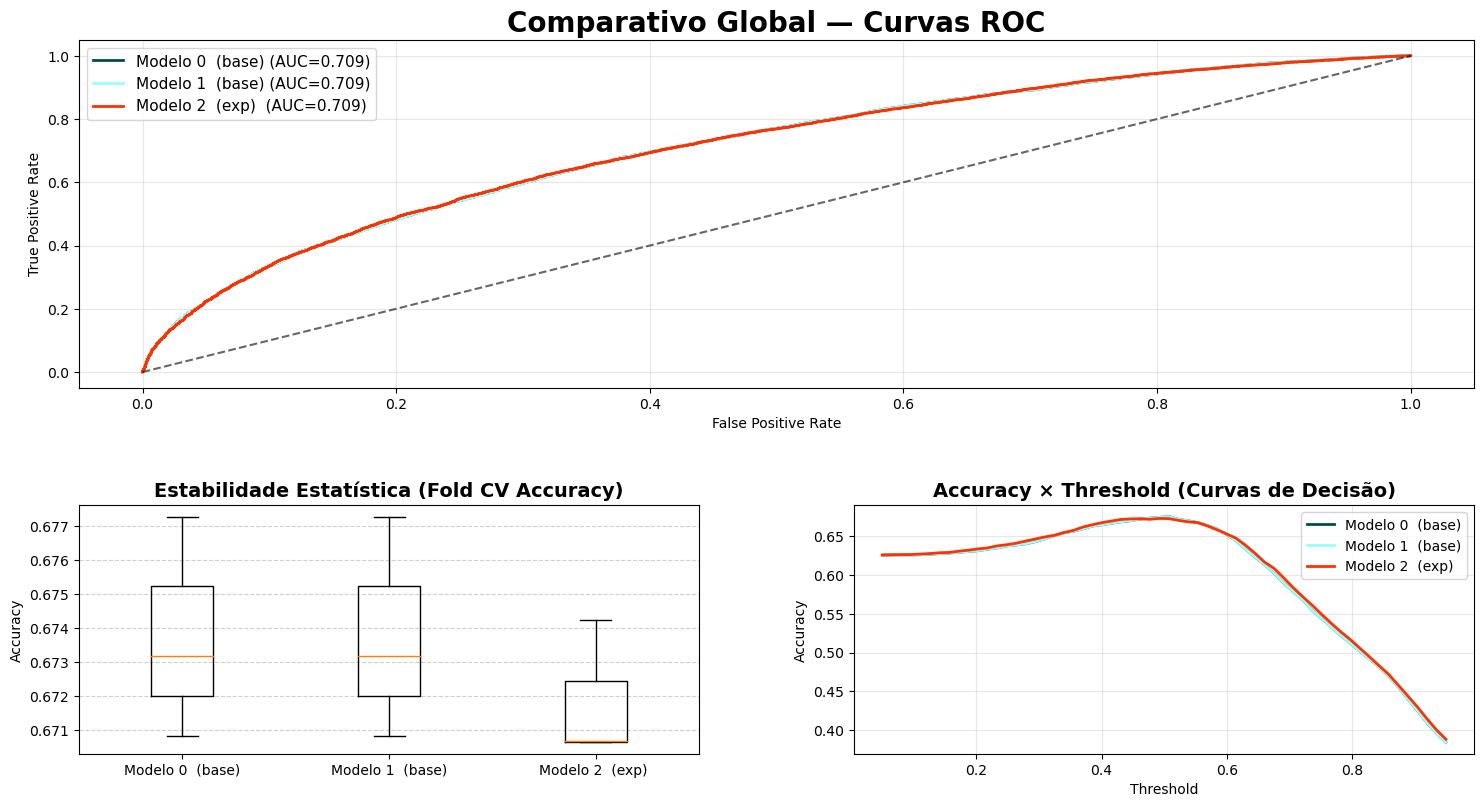

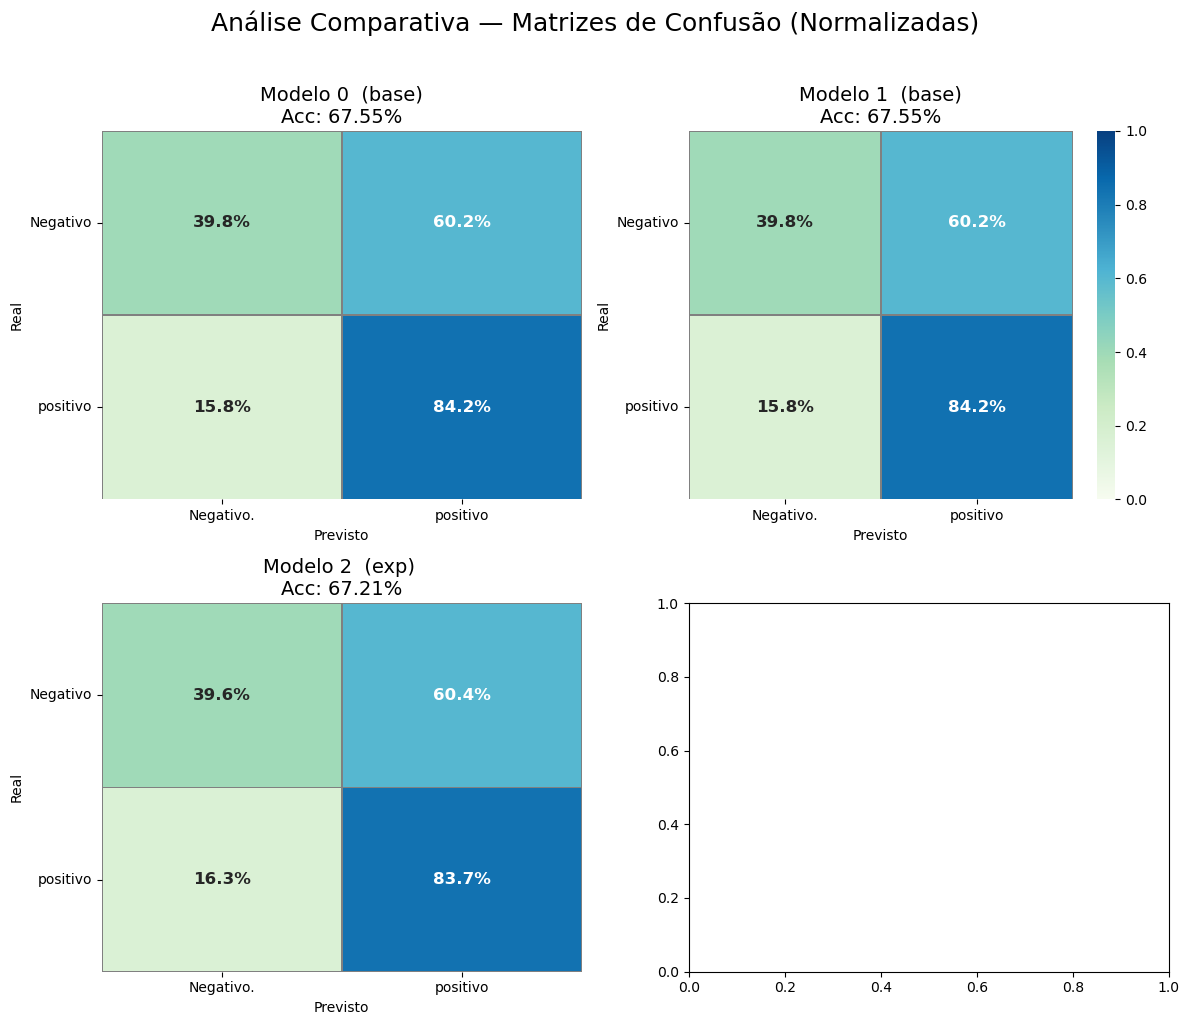

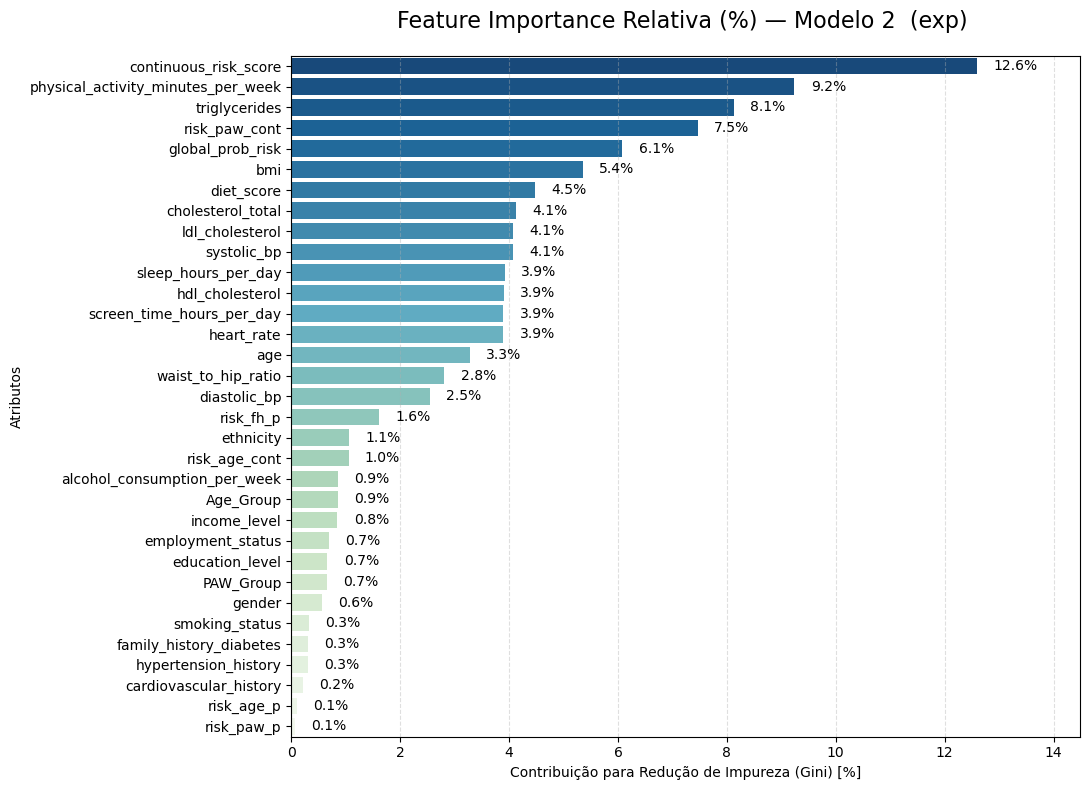


#Processo finalizado em: 16:42:06


In [6]:
#plotagem dos resultados
importances=model_evaluation_grid(
    models_list=models_list,
    X_test=X_val,
    y_test=y_val,
    best_model_pipeline=W[1],
    best_model_name=W[0]
)

---
## Modelo Vencedor: Modelo Modelo 2

O CatBoost mostrou-se a arquitetura mais resistente a ganhos via tuning com os parâmetros testados, operando de forma muito similar ao seu estado base.
* **Performance e Tuning:** O Modelo 2 obteve um **Test ROC-AUC de 0.7094**, um ganho nominal de apenas **+0.0003** sobre o Baseline. 
* **Significância:** A análise estatística confirmou que a melhoria é **não significativa (p = 0.0769)**. A nuance importante é que o CatBoost, por padrão, já possui uma excelente gestão de variáveis categóricas, o que deixa pouco espaço para ganhos expressivos apenas com ajuste de hiperparâmetros sem mudanças na engenharia de dados.
---

## 5. Considerações Finais

CatBoost demonstrou ser um modelo  estável e com alta capacidade de generalização, apresentando baixa discrepâncias entre os resultados de treino e teste. Essa robustez é evidenciada pela performance consistente mantida entre as diferentes dobras de validação cruzada e o conjunto de teste final.

**Análise de Generalização (Validação Cruzada)**
* A variabilidade (Std) foi muito baixa (0.0018), sugerindo que o modelo é pouco sensível a variações nas amostras de treino.
* O p-value de 0.0769 confirma que a busca exploratória (Random Search) não trouxe ganhos disruptivos sobre o Baseline, o que atesta a excelente configuração inicial do CatBoost.

**Interpretação e Relevância das Variáveis**
O modelo identificou um conjunto de variáveis biológicas e de comportamento como motores do risco:
* **continuous_risk_score (12.59%):** Principal preditor, validando a eficácia da engenharia de atributos realizada no preprocessador.
* **Atividade Física (9.24%) e Triglicerídeos (8.12%):** Fatores de estilo de vida e biomarcadores que superaram em relevância fatores tradicionais como idade isolada.
* **Variáveis Socioeconômicas:** Etnias e status de emprego tiveram peso residual, focando o modelo em métricas fisiológicas diretas.

**Conclusões Práticas**
* **Estabilidade como Vantagem:** O CatBoost é a escolha ideal se a prioridade for um modelo previsível e robusto contra variações nos dados.
* **Ajuste de Threshold:** O ganho de acurácia via threshold otimizado foi mínimo (0.6721 para 0.6711), sugerindo que o ponto de corte padrão (0.5) já está bem calibrado com a distribuição das classes.
* **Estratégia de Tuning:** Para este conjunto de dados, o esforço computacional em buscas exaustivas para o CatBoost ofereceu retorno marginal, recomendando-se o uso de parâmetros próximos ao baseline.



